# GraphEstimator rhoPCA preprocessor comparison

This notebook fixes the graph feature extractor to `neighborhood(radius=(0, 2))` and compares downstream classifiers with raw features, unsupervised SVD preprocessing, and supervised `RhoPCA` preprocessing.

The benchmark grid is:

- no preprocessor vs `TruncatedSVD` vs `RhoPCA`
- logistic regression, random forest, and RBF SVM

The dataset loader uses local PubChem assay graph exports through `abstractgraph-graphicalizer`.

In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]

repo_root, workspace_root

(PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/abstractgraph-ecosystem/repos/abstractgraph-ml'),
 PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/abstractgraph-ecosystem/repos'))

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import SVC

from abstractgraph.operators import neighborhood
from abstractgraph.vectorize import AbstractGraphTransformer
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_ml.rho_pca import RhoPCA
from abstractgraph_graphicalizer.chem import PubChemAssayLoader

/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


## Dataset

Pick one binary graph classification dataset. The default assay id matches other PubChem examples in this repo when present; otherwise the first available assay is used.

In [3]:
loader = PubChemAssayLoader(on_error="skip")
available_assay_ids = loader.available_assay_ids()
if not available_assay_ids:
    raise RuntimeError(f"No local PubChem assays found under {loader.root}")

preferred_assay_id = "651741"
assay_id = preferred_assay_id if preferred_assay_id in available_assay_ids else available_assay_ids[0]
limit_per_class = 500

graphs, targets = loader.load(assay_id, limit=limit_per_class)
targets = np.asarray(targets, dtype=int)

print("root:", loader.root)
print("assay_id:", assay_id)
print("graphs:", len(graphs))
pd.Series(targets).map({0: "inactive", 1: "active"}).value_counts().rename_axis("label").to_frame("count")

root: /Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/abstractgraph-ecosystem/repos/abstractgraph-graphicalizer/data/PUBCHEM
assay_id: 651741
graphs: 998


,count
label,
inactive,500
active,498


## Fixed graph transformer

All runs use exactly the same structural representation: `neighborhood(radius=(0, 2))`. The only representation variable is whether the estimator receives those features directly, through unsupervised SVD, or through supervised `RhoPCA`.

In [4]:
NBITS = 14
SVD_COMPONENTS = 256
RHO_COMPONENTS = 256
N_SPLITS = 3
TEST_SIZE = 0.30
RANDOM_STATE = 0


def make_transformer():
    return AbstractGraphTransformer(
        nbits=NBITS,
        decomposition_function=neighborhood(radius=(0, 2)),
        return_dense=True,
        n_jobs=-1,
    )


def make_noop_postprocessor():
    return FunctionTransformer(validate=False)


def make_svd():
    return TruncatedSVD(
        n_components=SVD_COMPONENTS,
        random_state=RANDOM_STATE,
    )


def make_rhopca():
    return RhoPCA(
        n_components=RHO_COMPONENTS,
        target_label=1,
        background_label=0,
        reg=1e-4,
        standardize=True,
    )

In [5]:
estimator_specs = {
    "linear_logistic": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "rbf_svm": SVC(
        kernel="rbf",
        C=10.0,
        gamma="scale",
        class_weight="balanced",
    ),
}

preprocessor_specs = {
    "none": None,
    "svd": make_svd,
    "rhopca": make_rhopca,
}

list(estimator_specs), list(preprocessor_specs)

(['linear_logistic', 'random_forest', 'rbf_svm'], ['none', 'svd', 'rhopca'])

## Benchmark helper

`GraphEstimator.predict_proba(...)` is used for ROC-AUC. For estimators such as `SVC` that expose `decision_function` but not native probabilities, `GraphEstimator` converts scores to probability-like outputs.

In [6]:
def make_graph_estimator(estimator_name, preprocessor_name):
    preprocessor_spec = preprocessor_specs[preprocessor_name]
    preprocessor = preprocessor_spec() if callable(preprocessor_spec) else preprocessor_spec

    return GraphEstimator(
        transformer=make_transformer(),
        estimator=clone(estimator_specs[estimator_name]),
        preprocessor=preprocessor,
        postprocessor=make_noop_postprocessor(),
        n_selected_features=None,
    )


def evaluate_config(estimator_name, preprocessor_name, graphs, targets):
    splitter = StratifiedShuffleSplit(
        n_splits=N_SPLITS,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    rows = []
    for split_idx, (train_idx, test_idx) in enumerate(splitter.split(np.zeros(len(targets)), targets), start=1):
        train_graphs = [graphs[i] for i in train_idx]
        test_graphs = [graphs[i] for i in test_idx]
        y_train = targets[train_idx]
        y_test = targets[test_idx]

        model = make_graph_estimator(estimator_name, preprocessor_name)
        start = perf_counter()
        model.fit(train_graphs, y_train)
        elapsed_fit = perf_counter() - start

        start = perf_counter()
        y_pred = model.predict(test_graphs)
        y_score = model.predict_proba(test_graphs)[:, 1]
        elapsed_predict = perf_counter() - start

        rows.append(
            {
                "assay_id": assay_id,
                "split": split_idx,
                "transformer": "neighborhood(radius=(0, 2))",
                "nbits": NBITS,
                "estimator": estimator_name,
                "preprocessor": preprocessor_name,
                "accuracy": accuracy_score(y_test, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
                "roc_auc": roc_auc_score(y_test, y_score),
                "fit_seconds": elapsed_fit,
                "predict_seconds": elapsed_predict,
            }
        )
    return rows

In [7]:
%%time

rows = []
for estimator_name in estimator_specs:
    for preprocessor_name in preprocessor_specs:
        print(f"{estimator_name:16s}  preprocessor={preprocessor_name}")
        rows.extend(evaluate_config(estimator_name, preprocessor_name, graphs, targets))

results = pd.DataFrame(rows)
results

linear_logistic   preprocessor=none
linear_logistic   preprocessor=svd
linear_logistic   preprocessor=rhopca
random_forest     preprocessor=none
random_forest     preprocessor=svd
random_forest     preprocessor=rhopca
rbf_svm           preprocessor=none
rbf_svm           preprocessor=svd
rbf_svm           preprocessor=rhopca
CPU times: user 15h 54min 12s, sys: 15min 7s, total: 16h 9min 20s
Wall time: 2h 32min 44s


,assay_id,split,transformer,nbits,estimator,preprocessor,accuracy,balanced_accuracy,roc_auc,fit_seconds,predict_seconds
0,651741,1,"neighborhood(radius=(0, 2))",14,linear_logistic,none,0.733333,0.733333,0.808622,34.485615,22.090324
1,651741,2,"neighborhood(radius=(0, 2))",14,linear_logistic,none,0.743333,0.743333,0.786067,26.129776,21.880313
2,651741,3,"neighborhood(radius=(0, 2))",14,linear_logistic,none,0.760000,0.760000,0.820400,31.255985,26.233664
3,651741,1,"neighborhood(radius=(0, 2))",14,linear_logistic,svd,0.776667,0.776667,0.830133,39.355668,31.867379
4,651741,2,"neighborhood(radius=(0, 2))",14,linear_logistic,svd,0.746667,0.746667,0.800689,44.607192,36.601745
5,651741,3,"neighborhood(radius=(0, 2))",14,linear_logistic,svd,0.793333,0.793333,0.853467,54.879592,43.777243
6,651741,1,"neighborhood(radius=(0, 2))",14,linear_logistic,rhopca,0.703333,0.703333,0.767067,1575.555782,23.143090
7,651741,2,"neighborhood(radius=(0, 2))",14,linear_logistic,rhopca,0.680000,0.680000,0.749667,658.704727,19.462351
8,651741,3,"neighborhood(radius=(0, 2))",14,linear_logistic,rhopca,0.690000,0.690000,0.752578,655.409031,22.055636
9,651741,1,"neighborhood(radius=(0, 2))",14,random_forest,none,0.813333,0.813333,0.882333,21.278356,16.805931


In [8]:
summary = (
    results.groupby(["estimator", "preprocessor"], as_index=False)
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        fit_seconds_mean=("fit_seconds", "mean"),
        predict_seconds_mean=("predict_seconds", "mean"),
    )
    .sort_values("roc_auc_mean", ascending=False)
)

summary

,estimator,preprocessor,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,balanced_accuracy_std,fit_seconds_mean,predict_seconds_mean
6,rbf_svm,none,0.889770,0.023876,0.824444,0.025019,28.256656,30.121054
3,random_forest,none,0.883681,0.014536,0.803333,0.020276,22.584543,17.354522
8,rbf_svm,svd,0.876378,0.023284,0.805556,0.008389,26.968341,20.327777
2,linear_logistic,svd,0.828096,0.026448,0.772222,0.023649,46.280817,37.415456
5,random_forest,svd,0.824593,0.018385,0.776667,0.006667,25.499753,18.278501
0,linear_logistic,none,0.805030,0.017446,0.745556,0.013472,30.623792,23.401434
4,random_forest,rhopca,0.796519,0.013510,0.693333,0.021858,1046.298266,27.361990
7,rbf_svm,rhopca,0.794733,0.021386,0.736667,0.018559,642.318107,26.324723
1,linear_logistic,rhopca,0.756437,0.009320,0.691111,0.011706,963.223180,21.553692


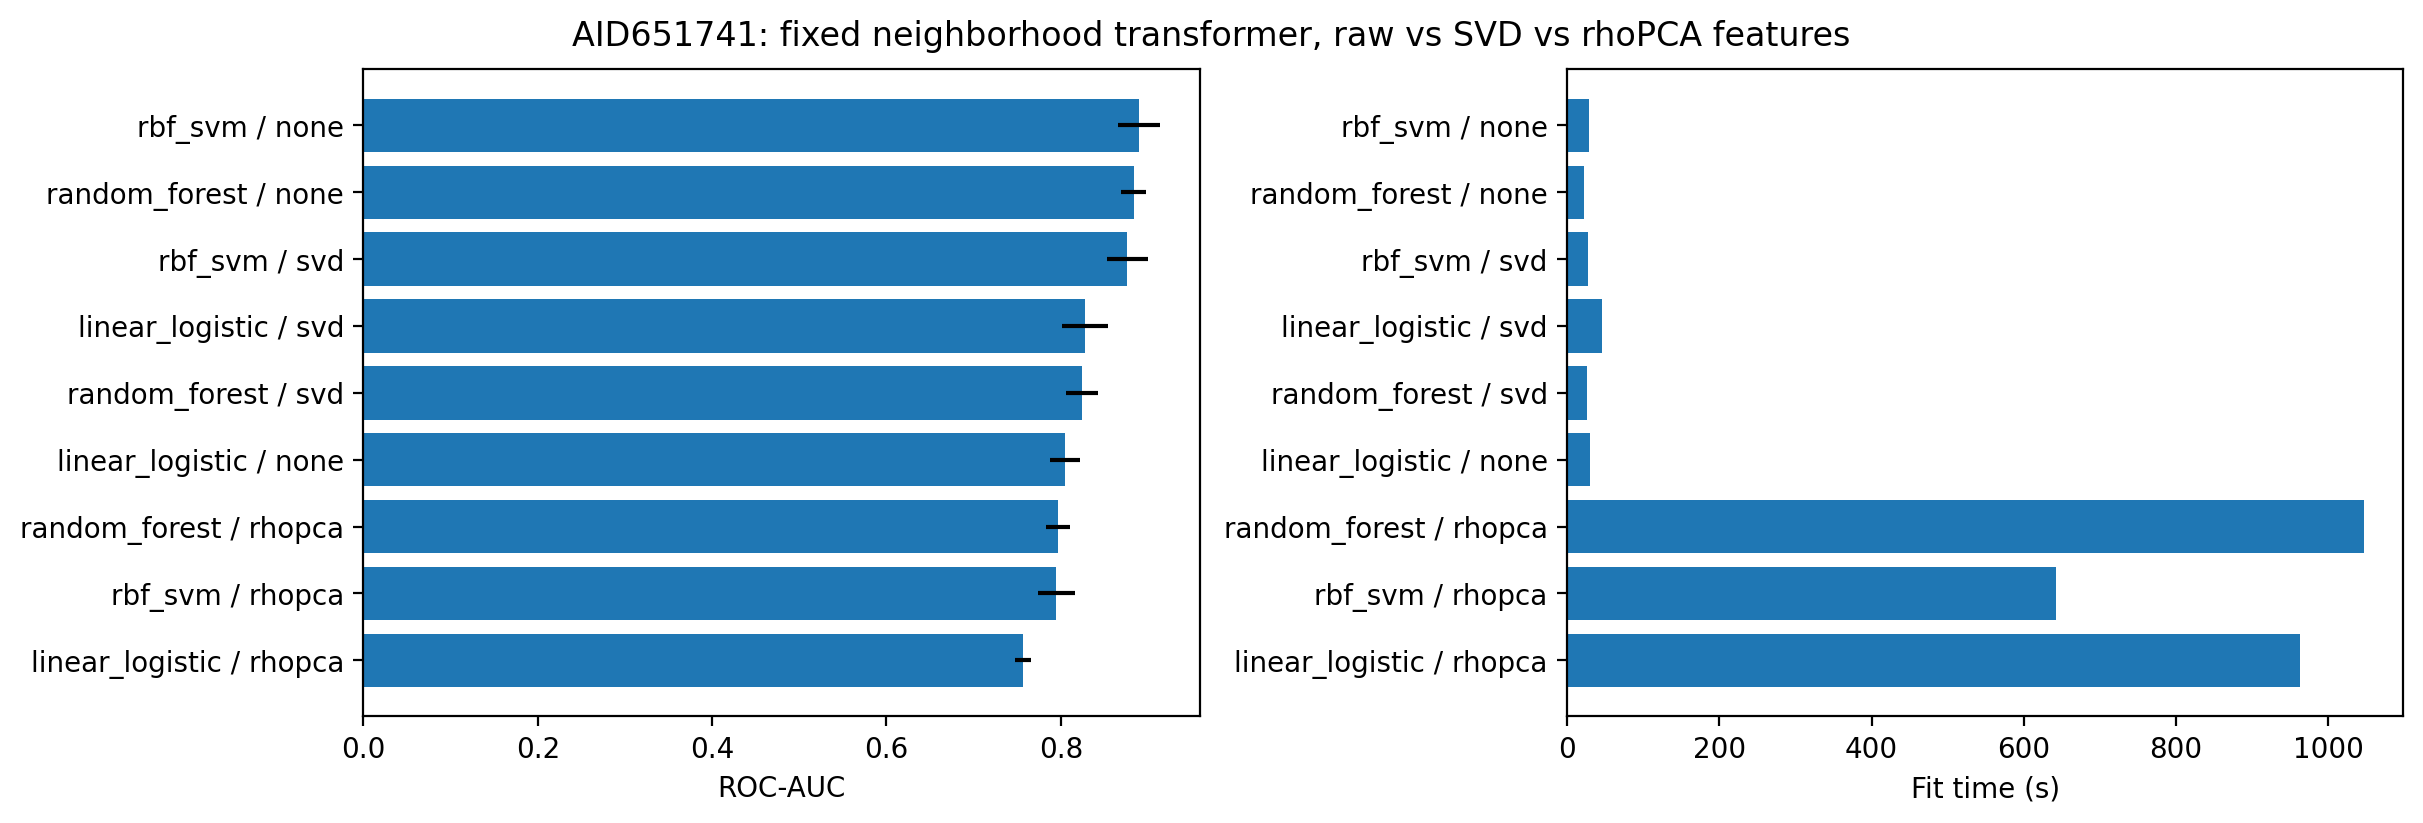

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

plot_df = summary.copy()
plot_df["method"] = plot_df["estimator"] + " / " + plot_df["preprocessor"]

axes[0].barh(plot_df["method"], plot_df["roc_auc_mean"], xerr=plot_df["roc_auc_std"].fillna(0.0))
axes[0].set_xlabel("ROC-AUC")
axes[0].invert_yaxis()

axes[1].barh(plot_df["method"], plot_df["fit_seconds_mean"])
axes[1].set_xlabel("Fit time (s)")
axes[1].invert_yaxis()

fig.suptitle(f"AID{assay_id}: fixed neighborhood transformer, raw vs SVD vs rhoPCA features")
plt.show()

In [10]:
results_path = repo_root / "notebooks" / "examples" / f"rhopca_preprocessor_comparison_AID{assay_id}.csv"
summary_path = repo_root / "notebooks" / "examples" / f"rhopca_preprocessor_comparison_AID{assay_id}_summary.csv"

results.to_csv(results_path, index=False)
summary.to_csv(summary_path, index=False)

results_path, summary_path

(PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/abstractgraph-ecosystem/repos/abstractgraph-ml/notebooks/examples/rhopca_preprocessor_comparison_AID651741.csv'),
 PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/abstractgraph-ecosystem/repos/abstractgraph-ml/notebooks/examples/rhopca_preprocessor_comparison_AID651741_summary.csv'))